In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [97]:
df_dist_vs_disparity_train = pd.read_csv("./train_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_train = pd.read_csv("./train_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_train = pd.read_csv("./train_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

df_dist_vs_disparity_test = pd.read_csv("./test_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_test = pd.read_csv("./test_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_test = pd.read_csv("./test_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

In [98]:
def fit_reg(X_train, y_train, X_test, y_test):
    result = {}
    
    for deg in range(1,9):
        coeff = np.polyfit(X_train, y_train , deg=deg)
        # Create polynomial function
        p = np.poly1d(coeff)
        y_hat = p(X_test)
        RMSE = np.sqrt(mean_squared_error(y_test, y_hat))
        print(RMSE)
        result[RMSE] = p
        
    return result

# Fitting the polynomial to estimate depth (mm) from disparity (px). Identify the best performing degree of polynomial by evaluating against test data.

In [99]:
reg_models = {}

In [100]:
X_train = df_dist_vs_disparity_train['x_disparity_px']
X_test = df_dist_vs_disparity_test['x_disparity_px']
y_train = df_dist_vs_disparity_train['dist_mm']
y_test = df_dist_vs_disparity_test['dist_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse] 

774.7174433628754
352.6806375643821
161.46290829338477
87.39766865392464
66.30095951577093
63.513206930619965
63.356153226932065
63.367349189155824


In [101]:
reg_models['disparity_to_depth'] = best_p

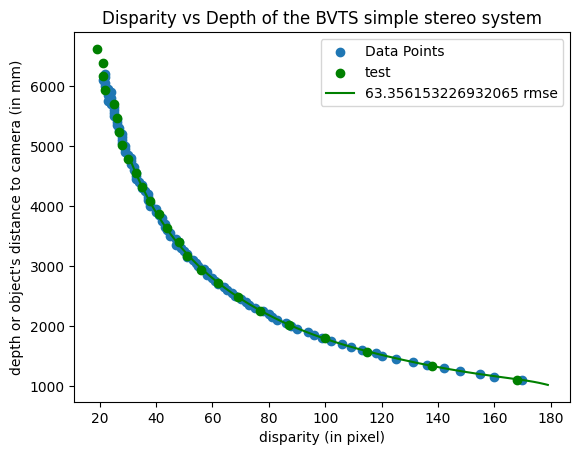

In [102]:
xp = np.arange(31, 180, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test, label=f'test', color='green')                       
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.xlabel("disparity (in pixel)")
plt.ylabel("depth or object's distance to camera (in mm)")
plt.title("Disparity vs Depth of the BVTS simple stereo system")
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel width (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [103]:
X_train = df_depth_vs_px_width_train['dist_mm']
X_test = df_depth_vs_px_width_test['dist_mm']
y_train = df_depth_vs_px_width_train['pixel_width_mm']
y_test = df_depth_vs_px_width_test['pixel_width_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.04499933451630222
0.04534919576840856
0.043858782699876336
0.04563959608994731
0.04700644476507838
0.04800336067420985
0.04308792025499665
0.11704373852762497


In [104]:
reg_models['depth_to_px_width_coeff'] = best_p

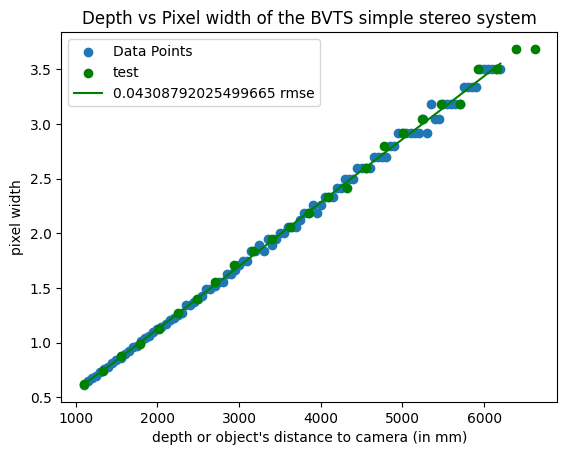

In [105]:
xp = np.arange(1100, 6200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test, label=f'test', color='green')     
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.xlabel("depth or object's distance to camera (in mm)")
plt.ylabel("pixel width")
plt.title("Depth vs Pixel width of the BVTS simple stereo system")
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel height (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [106]:
X_train = df_depth_vs_px_height_train['dist_mm']
X_test = df_depth_vs_px_height_test['dist_mm']
y_train = df_depth_vs_px_height_train['pixel_height_mm']
y_test = df_depth_vs_px_height_test['pixel_height_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.039145578661548275
0.037454718383653565
0.03854146168057633
0.04065450983968254
0.03799013033367964
0.06413865772882102
0.13858233072635154
0.16123156730411314


In [107]:
reg_models['depth_to_px_height_coeff'] = best_p

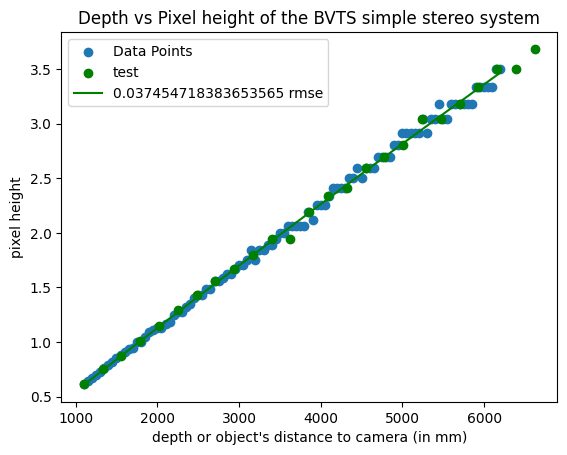

In [108]:
xp = np.arange(1100, 6200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test, label=f'test', color='green')     
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.xlabel("depth or object's distance to camera (in mm)")
plt.ylabel("pixel height")
plt.title("Depth vs Pixel height of the BVTS simple stereo system")
plt.show()

In [109]:
reg_models

{'disparity_to_depth': poly1d([-4.14360961e-11,  3.23718486e-08, -1.06442454e-05,  1.91771336e-03,
        -2.06693929e-01,  1.36900759e+01, -5.54151515e+02,  1.34351683e+04]),
 'depth_to_px_width_coeff': poly1d([-1.71445070e-25,  4.44333667e-21, -4.73322413e-17,  2.67694198e-13,
        -8.66859084e-10,  1.61152490e-06, -1.02709704e-03,  6.34483396e-01]),
 'depth_to_px_height_coeff': poly1d([-4.50220203e-09,  5.93584598e-04, -3.96248042e-02])}

In [110]:
import pickle
with open("fullframe_3d_reconstruction_regression_model.pkl", "wb") as models:    
        pickle.dump(reg_models, models, pickle.HIGHEST_PROTOCOL) # highest protocol version of pickle

# Final RMSE for:
* [RMSE here] :Model to estimate depth (mm) from disparity(px) 
* [RMSE here] :Model to estimate pixel width (mm) from depth(mm)
* [RMSE here] :Model to estimate pixel height (mm) from depth(mm)